# TCRAFT Paired-Chain oPool Library Design

Design one combinatorial oPool per peptide where **alpha and beta CDR3 sequences are encoded on a single oligo** (TCRAFT cloning strategy).

## Why this differs from the splitchain design

| | Splitchain | TCRAFT paired |
|-|------------|---------------|
| Alpha + beta | Separate oligos, randomly shuffled | Same oligo, explicitly linked |
| Diversity formula | alpha_div × beta_div (cross-product) | Σ unique_diversity per oligo (additive) |
| Epistasis exploitation | None — chains only co-occur by chance | Direct: synergistic positions share an oligo |
| Library size needed | ~√target per chain | Full target per peptide |

## Oligo tiers
| Tier | Description |
|------|-------------|
| tier1_backbone | Top positions from **both** chains co-varied on every oligo; diversity = product across all tier1 positions |
| tier2_ext | One oligo per extension: tier1 backbone + one extra position from either chain |
| tier3 | No viable IUPAC codon or not in budget; position stays at WT |

**Adapters** are not included here — they will be added externally once the cloning strategy is finalised.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict
from itertools import product
import warnings
warnings.filterwarnings('ignore')

NB_DIR   = Path('/cluster/project/reddy/marluca/NGS_pipeline/notebooks')
DATA_DIR = Path('/cluster/project/reddy/marluca/NGS_pipeline/data/P3620_LUCA-TCRDMF5-abDMS/04_variant_labeling')
OUT_DIR  = NB_DIR / 'opool_designs_tcraft'
OUT_DIR.mkdir(exist_ok=True)
print(f'Output: {OUT_DIR}')

Output: /cluster/project/reddy/marluca/NGS_pipeline/notebooks/opool_designs_tcraft


In [2]:
PEPTIDES = ['DRG01','DRG04','GIG01','GIG02','GIG03','GIG04','GIG05']

WT_ALPHA  = 'AVNFGGGKLI'
WT_BETA   = 'ASSLSFGTEAF'
ALPHA_LEN = len(WT_ALPHA)
BETA_LEN  = len(WT_BETA)

ENRICHMENT_COL = {p: 'enrich_pos1x_vs_neg' for p in PEPTIDES}
ENRICHMENT_COL['GIG02'] = 'enrich_pos2x_vs_neg'
PSEUDOCOUNT = 1e-3

# ── Design parameters ────────────────────────────────────────────────────
TARGET_DIVERSITY  = 10_000_000   # total unique paired sequences per peptide (soft goal)
MAX_DIVERSITY     = 15_000_000   # hard ceiling per peptide
MIN_SCORE         = 0.3    # min composite score to include a position as a candidate
K_MAX             = 8      # max candidate AAs pulled per position (pre-filter)
SYN_WEIGHT        = 0.5    # weight of synergy bonus in composite score
TIER1_FRAC        = 0.33   # backbone diversity cap as fraction of per-peptide target

STOP_PENALTY      = 10.0
EFFICIENCY_THRESH = 0.3

# Positions permanently excluded from Tier 1 (N-terminal positions)
TIER1_EXCLUDE = {
    'alpha': {0},
    'beta':  {0, 1},
}

TOP_K = 0
# Number of top-ranked enriched AAs (beyond WT) that MUST be encoded at each position.
#   TOP_K = 0  → only WT is a hard constraint
#   TOP_K = 1  → WT + top enriched AA

print(f'Alpha WT: {WT_ALPHA}  ({ALPHA_LEN} aa)')
print(f'Beta  WT: {WT_BETA}  ({BETA_LEN} aa)')
print(f'{len(PEPTIDES)} peptides: {PEPTIDES}')
print(f'Diversity target: {TARGET_DIVERSITY:,}  (hard cap: {MAX_DIVERSITY:,})')
print(f'Tier1 backbone cap: {TIER1_FRAC:.0%} of per-peptide target')
print(f'Tier1 excluded positions: alpha={sorted(TIER1_EXCLUDE.get("alpha", []))}  beta={sorted(TIER1_EXCLUDE.get("beta", []))}')
print(f'TOP_K: {TOP_K}')

Alpha WT: AVNFGGGKLI  (10 aa)
Beta  WT: ASSLSFGTEAF  (11 aa)
7 peptides: ['DRG01', 'DRG04', 'GIG01', 'GIG02', 'GIG03', 'GIG04', 'GIG05']
Diversity target: 10,000,000  (hard cap: 15,000,000)
Tier1 backbone cap: 33% of per-peptide target
Tier1 excluded positions: alpha=[0]  beta=[0, 1]
TOP_K: 0


## Genetic Code and IUPAC Utilities

In [3]:
GENETIC_CODE = {
    'ATA':'I','ATC':'I','ATT':'I','ATG':'M',
    'ACA':'T','ACC':'T','ACG':'T','ACT':'T',
    'AAC':'N','AAT':'N','AAA':'K','AAG':'K',
    'AGC':'S','AGT':'S','AGA':'R','AGG':'R',
    'CTA':'L','CTC':'L','CTG':'L','CTT':'L',
    'CCA':'P','CCC':'P','CCG':'P','CCT':'P',
    'CAC':'H','CAT':'H','CAA':'Q','CAG':'Q',
    'CGA':'R','CGC':'R','CGG':'R','CGT':'R',
    'GTA':'V','GTC':'V','GTG':'V','GTT':'V',
    'GCA':'A','GCC':'A','GCG':'A','GCT':'A',
    'GAC':'D','GAT':'D','GAA':'E','GAG':'E',
    'GGA':'G','GGC':'G','GGG':'G','GGT':'G',
    'TCA':'S','TCC':'S','TCG':'S','TCT':'S',
    'TTC':'F','TTT':'F','TTA':'L','TTG':'L',
    'TAC':'Y','TAT':'Y','TAA':'*','TAG':'*',
    'TGC':'C','TGT':'C','TGA':'*','TGG':'W',
}
IUPAC_BASES = {
    'A':{'A'},'C':{'C'},'G':{'G'},'T':{'T'},
    'R':{'A','G'},'Y':{'C','T'},'S':{'G','C'},'W':{'A','T'},
    'K':{'G','T'},'M':{'A','C'},
    'B':{'C','G','T'},'D':{'A','G','T'},'H':{'A','C','T'},'V':{'A','C','G'},
    'N':{'A','C','G','T'},
}

def decode_iupac(triplet):
    codons = [b1+b2+b3 for b1 in IUPAC_BASES[triplet[0]]
                        for b2 in IUPAC_BASES[triplet[1]]
                        for b3 in IUPAC_BASES[triplet[2]]]
    aas, stops = set(), 0
    for c in codons:
        aa = GENETIC_CODE.get(c,'?')
        if aa == '*': stops += 1
        else: aas.add(aa)
    return aas, stops/len(codons)

ALL_IUPAC = list(IUPAC_BASES.keys())
IUPAC_PROPS = {}
for _t in product(ALL_IUPAC, repeat=3):
    _triplet = ''.join(_t)
    _aas, _sf = decode_iupac(_triplet)
    if _aas:
        IUPAC_PROPS[_triplet] = {'aas': frozenset(_aas), 'stop_frac': _sf}

print(f'Pre-computed {len(IUPAC_PROPS)} valid IUPAC triplets')

Pre-computed 3370 valid IUPAC triplets


## Load Enrichment Data

In [4]:
def load_single_effects(pep_list):
    result = {}
    for pep in pep_list:
        df  = pd.read_csv(DATA_DIR / f'{pep}.variant_labeling.csv')
        col = ENRICHMENT_COL[pep]
        if col not in df.columns: col = 'enrich_pos1x_vs_neg'
        df['log2e']     = np.log2(df[col].clip(lower=PSEUDOCOUNT))
        baseline        = df['log2e'].mean()
        df['log2e_dev'] = df['log2e'] - baseline
        rows = []
        for _, r in df.iterrows():
            v = r['log2e_dev']
            aseq, bseq = r['alpha_aa'], r['beta_aa']
            if aseq != WT_ALPHA:
                for pos in range(ALPHA_LEN):
                    if aseq[pos] != WT_ALPHA[pos]:
                        rows.append(('alpha', pos, aseq[pos], v)); break
            if bseq != WT_BETA:
                for pos in range(BETA_LEN):
                    if bseq[pos] != WT_BETA[pos]:
                        rows.append(('beta', pos, bseq[pos], v)); break
        fx = (pd.DataFrame(rows, columns=['chain','position','aa','log2e_dev'])
              .groupby(['chain','position','aa'])['log2e_dev']
              .agg(log2fc='mean', n_variants='count').reset_index())
        result[pep] = fx
    return result

print('Loading single effects...')
try:
    print(f'Done. DRG01: {len(SINGLE_FX["DRG01"])} entries')
except Exception as e:
    print(f'Error loading DRG01: {e}')
    SINGLE_FX = load_single_effects(PEPTIDES)
    print(f'Done. DRG01: {len(SINGLE_FX["DRG01"])} entries')

SINGLE_FX['DRG01'].head(6)

Loading single effects...
Error loading DRG01: name 'SINGLE_FX' is not defined
Done. DRG01: 399 entries


,chain,position,aa,log2fc,n_variants
0,alpha,0,C,0.117227,100
1,alpha,0,D,0.072407,73
2,alpha,0,E,-0.145926,106
3,alpha,0,F,0.188084,123
4,alpha,0,G,3.041486,175
5,alpha,0,H,0.565789,87


## Compute Epistasis (Synergy)

In [5]:
def compute_epistasis(pep_list):
    result = {}
    for pep in pep_list:
        df  = pd.read_csv(DATA_DIR / f'{pep}.variant_labeling.csv')
        col = ENRICHMENT_COL[pep]
        if col not in df.columns: col = 'enrich_pos1x_vs_neg'
        df['log2e']     = np.log2(df[col].clip(lower=PSEUDOCOUNT))
        baseline        = df['log2e'].mean()
        df['log2e_dev'] = df['log2e'] - baseline
        fx = SINGLE_FX[pep].set_index(['chain','position','aa'])['log2fc'].to_dict()
        rows = []
        for _, r in df.iterrows():
            aseq, bseq = r['alpha_aa'], r['beta_aa']
            if aseq == WT_ALPHA or bseq == WT_BETA: continue
            apos = aaa = bpos = baa = None
            for pos in range(ALPHA_LEN):
                if aseq[pos] != WT_ALPHA[pos]: apos, aaa = pos, aseq[pos]; break
            for pos in range(BETA_LEN):
                if bseq[pos] != WT_BETA[pos]: bpos, baa = pos, bseq[pos]; break
            if apos is None or bpos is None: continue
            ma = fx.get(('alpha', apos, aaa), 0.0)
            mb = fx.get(('beta',  bpos, baa), 0.0)
            obs = r['log2e_dev']
            rows.append({'alpha_pos': apos, 'aa_alpha': aaa,
                         'beta_pos':  bpos, 'aa_beta':  baa,
                         'log2fc_obs': obs, 'log2fc_exp': ma+mb,
                         'epistasis': obs - (ma+mb)})
        result[pep] = pd.DataFrame(rows)
    return result

try:
    print('Loading epistasis...')
    print(f'Done. DRG01: {len(EPISTASIS["DRG01"])} pairs')
except Exception as e:
    print(f'Error loading DRG01 epistasis: {e}')
    print('Computing epistasis...')
    EPISTASIS = compute_epistasis(PEPTIDES)
    print(f'Done. DRG01: {len(EPISTASIS["DRG01"])} pairs')
EPISTASIS['DRG01'].head(6)

Loading epistasis...
Error loading DRG01 epistasis: name 'EPISTASIS' is not defined
Computing epistasis...
Done. DRG01: 30317 pairs


,alpha_pos,aa_alpha,beta_pos,aa_beta,log2fc_obs,log2fc_exp,epistasis
0,1,A,1,A,2.289790,2.896811,-0.607021
1,1,C,1,A,4.988507,1.362625,3.625882
2,1,E,1,A,-2.625310,-0.788783,-1.836527
3,1,F,1,A,-2.625310,-0.435898,-2.189412
4,1,G,1,A,-4.270127,-0.198898,-4.071229
5,1,H,1,A,-3.451897,-0.658752,-2.793145


## Pool Enrichment and Composite Scores

In [6]:
def synergy_bonus_for_chain(pep_list, chain, min_epi=0.2):
    all_epi = pd.concat([EPISTASIS[p] for p in pep_list if not EPISTASIS[p].empty], ignore_index=True)
    if chain == 'alpha': pos_col, aa_col, opos_col = 'alpha_pos','aa_alpha','beta_pos'
    else:                pos_col, aa_col, opos_col = 'beta_pos', 'aa_beta', 'alpha_pos'
    pooled = all_epi.groupby([pos_col, aa_col, opos_col])['epistasis'].mean().reset_index()
    syn = defaultdict(float)
    for _, row in pooled.iterrows():
        if row['epistasis'] > min_epi:
            syn[(int(row[pos_col]), row[aa_col])] += row['epistasis']
    return dict(syn)


def pool_composite_scores(pep_list, chain):
    chain_dfs = [SINGLE_FX[p][SINGLE_FX[p]['chain']==chain] for p in pep_list if p in SINGLE_FX]
    pooled = (pd.concat(chain_dfs, ignore_index=True)
              .groupby(['position','aa'])['log2fc'].mean().reset_index()
              .rename(columns={'log2fc':'base_score'}))
    syn_raw = synergy_bonus_for_chain(pep_list, chain)
    pooled['syn_raw'] = pooled.apply(lambda r: syn_raw.get((int(r['position']), r['aa']), 0.0), axis=1)
    pooled['z_base'] = (pooled['base_score'] - pooled['base_score'].mean()) / pooled['base_score'].std()
    syn_std = pooled['syn_raw'].std()
    pooled['z_syn'] = (pooled['syn_raw'] - pooled['syn_raw'].mean()) / (syn_std if syn_std > 0 else 1.0)
    pooled['composite'] = pooled['z_base'] + SYN_WEIGHT * pooled['z_syn']
    return pooled.sort_values(['position','composite'], ascending=[True,False])


print(f'{PEPTIDES[0]} alpha composite scores (top 8):')
print(pool_composite_scores([PEPTIDES[0]],'alpha').nlargest(8,'composite').to_string(index=False))
print(f'\n{PEPTIDES[0]} beta composite scores (top 8):')
print(pool_composite_scores([PEPTIDES[0]],'beta').nlargest(8,'composite').to_string(index=False))

DRG01 alpha composite scores (top 8):
 position aa  base_score  syn_raw   z_base    z_syn  composite
        1  A    3.553340 6.394535 3.713047 2.085172   4.755633
        7  V    2.968999 7.636001 3.103643 3.046873   4.627079
        7  L    2.797201 7.093659 2.924476 2.626748   4.237850
        3  M    2.959117 6.438459 3.093337 2.119198   4.152936
        9  L    3.180584 5.613513 3.324303 1.480153   4.064380
        0  G    3.041486 5.860815 3.179239 1.671726   4.015102
        8  M    2.292514 7.613234 2.398143 3.029236   3.912761
        7  M    2.498668 6.895950 2.613139 2.473593   3.849935

DRG01 beta composite scores (top 8):
 position aa  base_score  syn_raw   z_base    z_syn  composite
        4  V    4.702643 8.735781 4.688997 3.881535   6.629765
        4  L    4.056235 8.518112 4.045446 3.725010   5.907951
        7  R    3.436143 8.937955 3.428095 4.026918   5.441554
        4  I    3.034241 7.829261 3.027970 3.229660   4.642800
        7  K    2.841278 8.082625 2.835860

## Paired oPool Design

Each oligo encodes the full alpha CDR3 + full beta CDR3 as a single sequence (63 nt, adapters added later).

**Joint position ranking**: positions from alpha and beta are ranked together by composite score.  
The backbone includes the highest-scoring positions from either chain until `TIER1_FRAC × TARGET_DIVERSITY` is reached.  
Extension oligos add one position at a time from whichever chain has the next-best candidate.

This means synergistic alpha+beta positions naturally share the same backbone oligo — no explicit epistasis filtering needed.

In [7]:
def _wt_triplets(wt_seq):
    t = {}
    for pos, aa in enumerate(wt_seq):
        for codon, enc_aa in GENETIC_CODE.items():
            if enc_aa == aa: t[pos] = codon; break
    return t


def _canonical_codon(pos, cands_by_pos, scores_by_pos, wt_aa=None, top_k=1):
    """Select the best IUPAC codon for a position (same as splitchain design)."""
    if pos not in cands_by_pos or not cands_by_pos[pos]:
        return None, frozenset(), 0.0
    top_aas   = [cands_by_pos[pos][i][0]
                 for i in range(min(top_k, len(cands_by_pos[pos])))]
    must_have = frozenset(top_aas) | (frozenset({wt_aa}) if wt_aa is not None else frozenset())
    pos_scores = scores_by_pos.get(pos, {})
    best_triplet, best_encoded, best_mean = None, frozenset(), -np.inf
    for triplet, props in IUPAC_PROPS.items():
        encoded = props['aas']
        if not must_have.issubset(encoded):
            continue
        mean_score = (
            sum(pos_scores.get(aa, 0.0) for aa in encoded)
            - STOP_PENALTY * props['stop_frac']
        ) / max(len(encoded), 1)
        if mean_score > best_mean:
            best_mean    = mean_score
            best_triplet = triplet
            best_encoded = encoded
    if best_triplet is None:
        return None, frozenset(), 0.0
    eff = len(must_have) / len(best_encoded)
    return best_triplet, frozenset(best_encoded), eff


def _make_paired_oligo(oligo_id, oligo_type, alpha_enc, beta_enc,
                       wt_alpha, wt_beta, wt_tri_alpha, wt_tri_beta):
    """
    Build one paired oligo.
    alpha_enc / beta_enc: pos -> (triplet, frozenset_aas, eff)  for varied positions only.
    All other positions take WT sequence.
    """
    alpha_len = len(wt_alpha)
    beta_len  = len(wt_beta)

    alpha_pos_aas = {p: frozenset({wt_alpha[p]}) for p in range(alpha_len)}
    beta_pos_aas  = {p: frozenset({wt_beta[p]})  for p in range(beta_len)}
    alpha_iupac   = dict(wt_tri_alpha)
    beta_iupac    = dict(wt_tri_beta)
    effs          = {}
    diversity     = 1

    for pos, (triplet, encoded, eff) in alpha_enc.items():
        alpha_pos_aas[pos] = encoded
        alpha_iupac[pos]   = triplet
        effs[('alpha', pos)] = eff
        diversity *= len(encoded)

    for pos, (triplet, encoded, eff) in beta_enc.items():
        beta_pos_aas[pos] = encoded
        beta_iupac[pos]   = triplet
        effs[('beta', pos)] = eff
        diversity *= len(encoded)

    alpha_dna = ''.join(alpha_iupac[p] for p in range(alpha_len))
    beta_dna  = ''.join(beta_iupac[p]  for p in range(beta_len))

    return {
        'oligo_id':           oligo_id,
        'oligo_type':         oligo_type,
        'alpha_position_aas': alpha_pos_aas,
        'beta_position_aas':  beta_pos_aas,
        'alpha_iupac':        alpha_iupac,
        'beta_iupac':         beta_iupac,
        'alpha_dna':          alpha_dna,
        'beta_dna':           beta_dna,
        'paired_dna':         alpha_dna + beta_dna,
        'diversity':          diversity,
        'codon_efficiency':   effs,
        'is_leaky':           any(e < EFFICIENCY_THRESH for e in effs.values()),
        'alpha_varied_pos':   sorted(p for p, aas in alpha_pos_aas.items() if len(aas) > 1),
        'beta_varied_pos':    sorted(p for p, aas in beta_pos_aas.items()  if len(aas) > 1),
        'n_alpha_varied':     sum(1 for aas in alpha_pos_aas.values() if len(aas) > 1),
        'n_beta_varied':      sum(1 for aas in beta_pos_aas.values()  if len(aas) > 1),
    }


def design_paired_pool(pep, wt_alpha, wt_beta, target_diversity, max_diversity):
    """
    Design a TCRAFT paired oPool for one peptide.

    Each oligo encodes both alpha and beta CDR3.  Positions from both chains
    compete for the same diversity budget; the highest-scoring positions
    (interleaved by composite score) go into the joint backbone.

    target_diversity — absolute paired diversity goal per peptide (soft).
    max_diversity    — hard ceiling; extensions checked against this.
    """
    wt_tri_alpha = _wt_triplets(wt_alpha)
    wt_tri_beta  = _wt_triplets(wt_beta)

    alpha_df = pool_composite_scores([pep], 'alpha')
    beta_df  = pool_composite_scores([pep], 'beta')

    # Build (chain, pos) → score/candidate dicts
    scores_by_key = {}   # (chain, pos) -> {aa -> composite}
    cands_by_key  = {}   # (chain, pos) -> [(aa, score), ...]
    for chain, df in [('alpha', alpha_df), ('beta', beta_df)]:
        for _, row in df.iterrows():
            key = (chain, int(row['position']))
            scores_by_key.setdefault(key, {})[row['aa']] = row['composite']
        for pos, grp in df.groupby('position'):
            top = (grp[grp['composite'] >= MIN_SCORE]
                   .nlargest(K_MAX, 'composite')[['aa', 'composite']].values.tolist())
            if top:
                cands_by_key[(chain, int(pos))] = top

    # Canonical IUPAC codon per (chain, pos)
    canon = {}
    for (chain, pos), cands in cands_by_key.items():
        wt_seq = wt_alpha if chain == 'alpha' else wt_beta
        t, enc, eff = _canonical_codon(
            pos, {pos: cands}, {pos: scores_by_key[(chain, pos)]},
            wt_aa=wt_seq[pos], top_k=TOP_K
        )
        if t is not None:
            canon[(chain, pos)] = (t, enc, eff)

    # Joint position list ranked by max composite score
    sorted_pos = sorted(
        cands_by_key,
        key=lambda k: max(sc for _, sc in cands_by_key[k]),
        reverse=True
    )
    n_pos = len(sorted_pos)

    tier1, tier2, tier3 = [], [], []
    tier1_div    = 1
    tier1_budget = int(target_diversity * TIER1_FRAC)

    # ── Tier 1: joint backbone ────────────────────────────────────────────
    for key in sorted_pos:
        chain_k, pos_k = key
        if key not in canon:
            tier3.append(key); continue
        if pos_k in TIER1_EXCLUDE.get(chain_k, set()):
            continue
        proposed = tier1_div * len(canon[key][1])
        if proposed > tier1_budget:
            continue
        tier1_div = proposed
        tier1.append(key)

    # ── Tier 2: extensions from either chain ─────────────────────────────
    # ext_budget driven by target_diversity (soft goal), not max_diversity.
    remaining = [k for k in sorted_pos if k not in set(tier1)]
    if TIER1_FRAC < 1.0:
        ext_budget = target_diversity - tier1_div
        for key in remaining:
            if key not in canon:
                tier3.append(key); continue
            cost = tier1_div * (len(canon[key][1]) - 1)
            if cost > ext_budget:
                continue  # would exceed target
            if tier1_div + cost > max_diversity:
                continue  # hard cap safety
            tier2.append(key)
            ext_budget -= cost

    in_t1t2 = set(tier1 + tier2)
    tier3 += [k for k in sorted_pos if k not in in_t1t2 and k not in tier3]

    total_div = tier1_div + sum(
        tier1_div * (len(canon[k][1]) - 1) for k in tier2 if k in canon
    )

    t1a = sorted(p for c, p in tier1 if c == 'alpha')
    t1b = sorted(p for c, p in tier1 if c == 'beta')
    t2a = sorted(p for c, p in tier2 if c == 'alpha')
    t2b = sorted(p for c, p in tier2 if c == 'beta')
    print(f'  {n_pos} enriched positions across both chains  [TOP_K={TOP_K}]')
    print(f'  Tier 1 ({len(tier1)} pos):  alpha={t1a}  beta={t1b}  — backbone div = {tier1_div:,}')
    print(f'  Tier 2 ({len(tier2)} pos):  alpha_ext={t2a}  beta_ext={t2b}')
    print(f'  Tier 3 ({len(tier3)} pos):  {tier3}')
    print(f'  Estimated diversity: {total_div:,}  (target {target_diversity:,}  max {max_diversity:,})')

    # ── Build oligos ──────────────────────────────────────────────────────
    def a_enc(keys):
        return {p: canon[('alpha', p)] for (c, p) in keys
                if c == 'alpha' and ('alpha', p) in canon}
    def b_enc(keys):
        return {p: canon[('beta', p)] for (c, p) in keys
                if c == 'beta' and ('beta', p) in canon}

    seen_dna = set()
    oligos   = []

    def add(oligo):
        if oligo['paired_dna'] not in seen_dna:
            seen_dna.add(oligo['paired_dna']); oligos.append(oligo); return True
        return False

    tier1_set = set(tier1)
    add(_make_paired_oligo(
        f'{pep}_backbone', 'tier1_backbone',
        a_enc(tier1_set), b_enc(tier1_set),
        wt_alpha, wt_beta, wt_tri_alpha, wt_tri_beta
    ))

    for key in tier2:
        chain_k, pos_k = key
        ext_set = tier1_set | {key}
        label   = f'{"a" if chain_k == "alpha" else "b"}p{pos_k:02d}'
        add(_make_paired_oligo(
            f'{pep}_ext_{label}', 'tier2_ext',
            a_enc(ext_set), b_enc(ext_set),
            wt_alpha, wt_beta, wt_tri_alpha, wt_tri_beta
        ))

    for o in oligos:
        if o['oligo_type'] == 'tier1_backbone':
            o['unique_diversity'] = o['diversity']
        else:
            o['unique_diversity'] = o['diversity'] - tier1_div

    if total_div < target_diversity * 0.7:
        print(f'  NOTE: diversity {total_div:,} is below 70% of target {target_diversity:,}')
    print(f'  Total oligos: {len(oligos)}')
    return oligos


print(f'Designing {len(PEPTIDES)} paired pools (one per peptide)...')
POOLS = {}
for pep in PEPTIDES:
    print(f'\n── {pep} ──')
    POOLS[pep] = design_paired_pool(pep, WT_ALPHA, WT_BETA, TARGET_DIVERSITY, MAX_DIVERSITY)

Designing 7 paired pools (one per peptide)...

── DRG01 ──
  16 enriched positions across both chains  [TOP_K=0]
  Tier 1 (12 pos):  alpha=[1, 3, 7, 8, 9]  beta=[2, 3, 4, 7, 8, 9, 10]  — backbone div = 1,935,360
  Tier 2 (3 pos):  alpha_ext=[0, 2]  beta_ext=[1]
  Tier 3 (1 pos):  [('beta', 0)]
  Estimated diversity: 7,741,440  (target 10,000,000  max 15,000,000)
  Total oligos: 4

── DRG04 ──
  17 enriched positions across both chains  [TOP_K=0]
  Tier 1 (12 pos):  alpha=[1, 3, 6, 7, 8, 9]  beta=[2, 3, 4, 7, 8, 10]  — backbone div = 2,867,200
  Tier 2 (1 pos):  alpha_ext=[0]  beta_ext=[]
  Tier 3 (4 pos):  [('beta', 1), ('beta', 9), ('beta', 0), ('alpha', 5)]
  Estimated diversity: 8,601,600  (target 10,000,000  max 15,000,000)
  Total oligos: 2

── GIG01 ──
  18 enriched positions across both chains  [TOP_K=0]
  Tier 1 (14 pos):  alpha=[1, 2, 3, 6, 7, 8, 9]  beta=[3, 4, 6, 7, 8, 9, 10]  — backbone div = 2,764,800
  Tier 2 (1 pos):  alpha_ext=[]  beta_ext=[2]
  Tier 3 (3 pos):  [('alph

## Diversity Check

In [8]:
print(f'{"Peptide":<8}  {"n_oligos":>9}  {"backbone_div":>14}  {"total_div":>11}  {"target":>11}  flag')
print('-' * 70)
for pep in PEPTIDES:
    pool     = POOLS[pep]
    backbone = next((o for o in pool if o['oligo_type'] == 'tier1_backbone'), None)
    bd       = backbone['diversity'] if backbone else '-'
    total    = sum(o['unique_diversity'] for o in pool)
    flag     = 'OVER MAX!' if total > MAX_DIVERSITY else ('OK' if total <= TARGET_DIVERSITY * 1.1 else 'above target')
    types    = {}
    for o in pool: types[o['oligo_type']] = types.get(o['oligo_type'], 0) + 1
    print(f'{pep:<8}  {len(pool):>9}  {bd:>14,}  {total:>11,}  {TARGET_DIVERSITY:>11,}  {flag}  {types}')

print()
print(f'Alpha CDR3 length: {ALPHA_LEN} aa = {ALPHA_LEN*3} nt')
print(f'Beta  CDR3 length: {BETA_LEN} aa = {BETA_LEN*3} nt')
print(f'Paired oligo DNA length (no adapters): {ALPHA_LEN*3 + BETA_LEN*3} nt')

Peptide    n_oligos    backbone_div    total_div       target  flag
----------------------------------------------------------------------
DRG01             4       1,935,360    7,741,440   10,000,000  OK  {'tier1_backbone': 1, 'tier2_ext': 3}
DRG04             2       2,867,200    8,601,600   10,000,000  OK  {'tier1_backbone': 1, 'tier2_ext': 1}
GIG01             2       2,764,800    8,294,400   10,000,000  OK  {'tier1_backbone': 1, 'tier2_ext': 1}
GIG02             3       1,990,656    9,953,280   10,000,000  OK  {'tier1_backbone': 1, 'tier2_ext': 2}
GIG03             2       3,145,728    9,437,184   10,000,000  OK  {'tier1_backbone': 1, 'tier2_ext': 1}
GIG04             3       3,041,280    9,123,840   10,000,000  OK  {'tier1_backbone': 1, 'tier2_ext': 2}
GIG05             3       1,728,000    8,640,000   10,000,000  OK  {'tier1_backbone': 1, 'tier2_ext': 2}

Alpha CDR3 length: 10 aa = 30 nt
Beta  CDR3 length: 11 aa = 33 nt
Paired oligo DNA length (no adapters): 63 nt


## Visualise: Paired Oligos

Each panel = one oligo.  Alpha positions (0-9) are shown on the left, beta positions (10-20) on the right, separated by a dashed line.
**■ grey** = WT residue.  **● coloured** = non-WT encoded AA.  **Shaded column** = variable position.

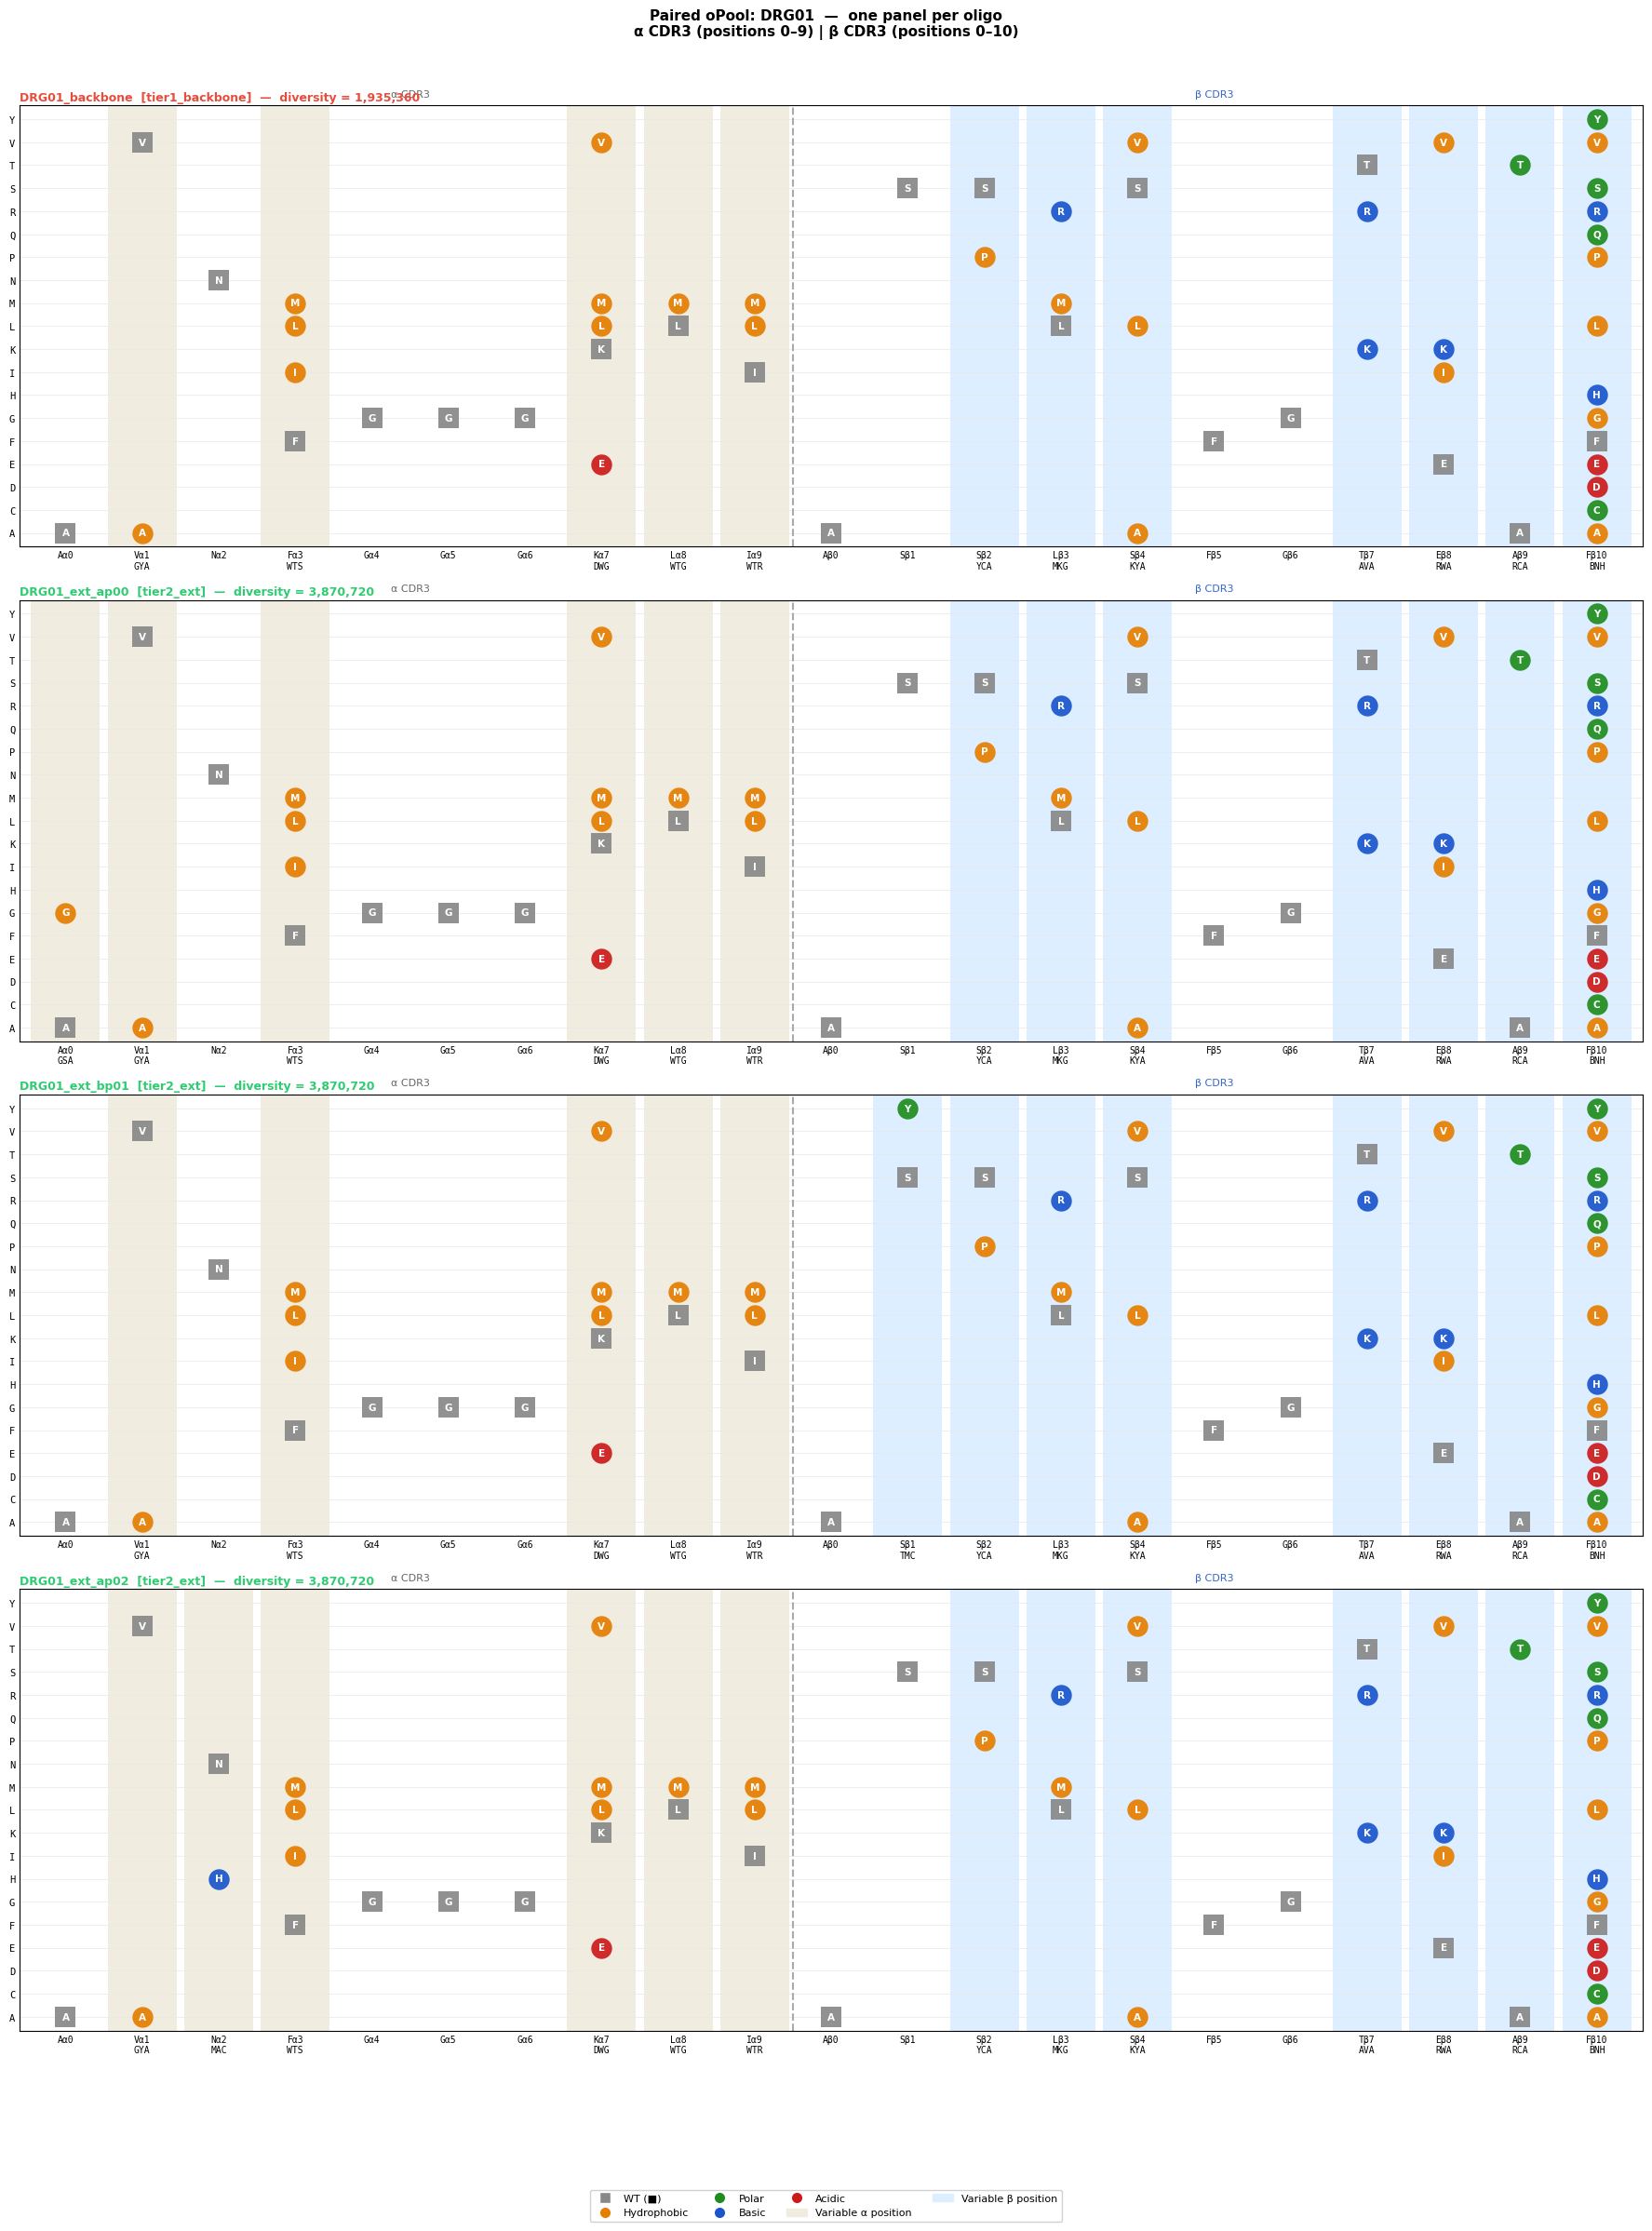

Saved → /cluster/project/reddy/marluca/NGS_pipeline/notebooks/opool_designs_tcraft/opool_paired_DRG01_t0.33_tk0_per_oligo.pdf


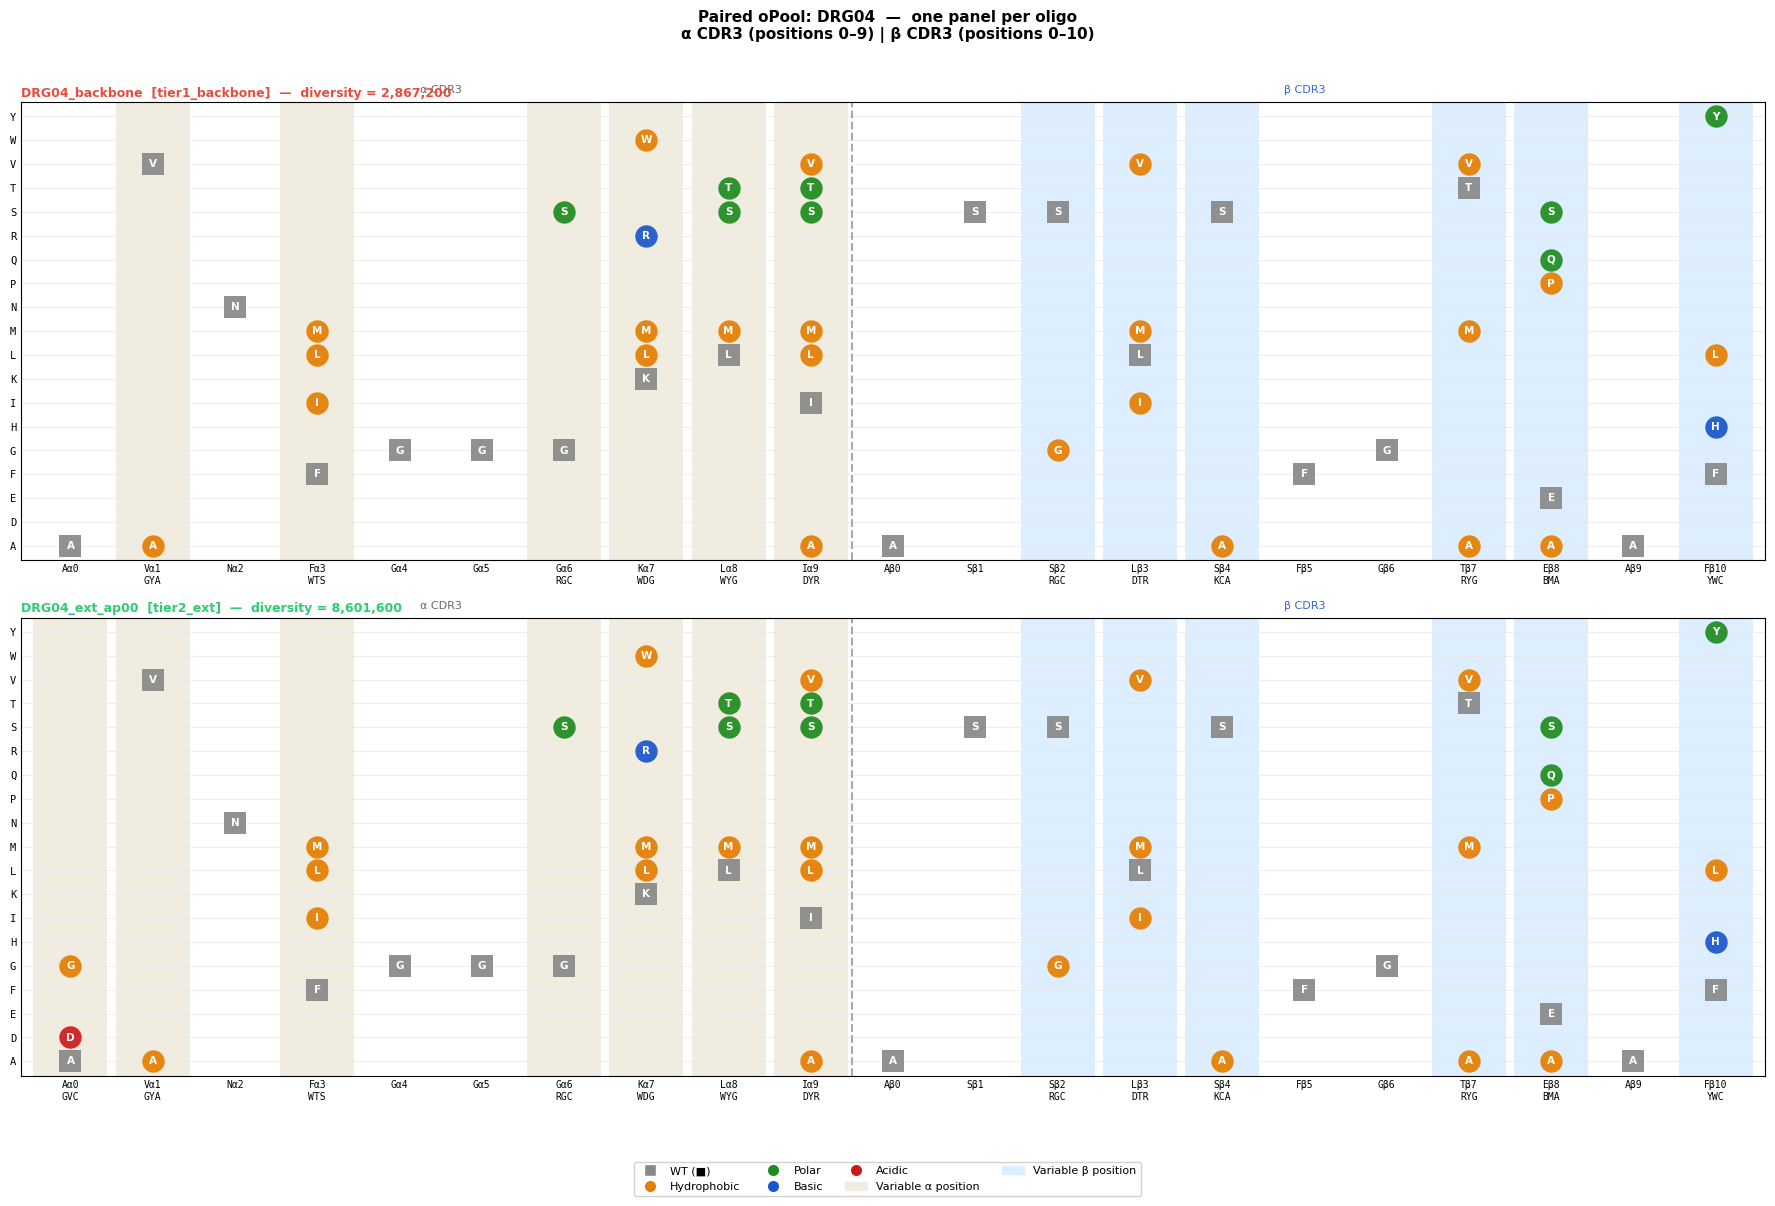

Saved → /cluster/project/reddy/marluca/NGS_pipeline/notebooks/opool_designs_tcraft/opool_paired_DRG04_t0.33_tk0_per_oligo.pdf


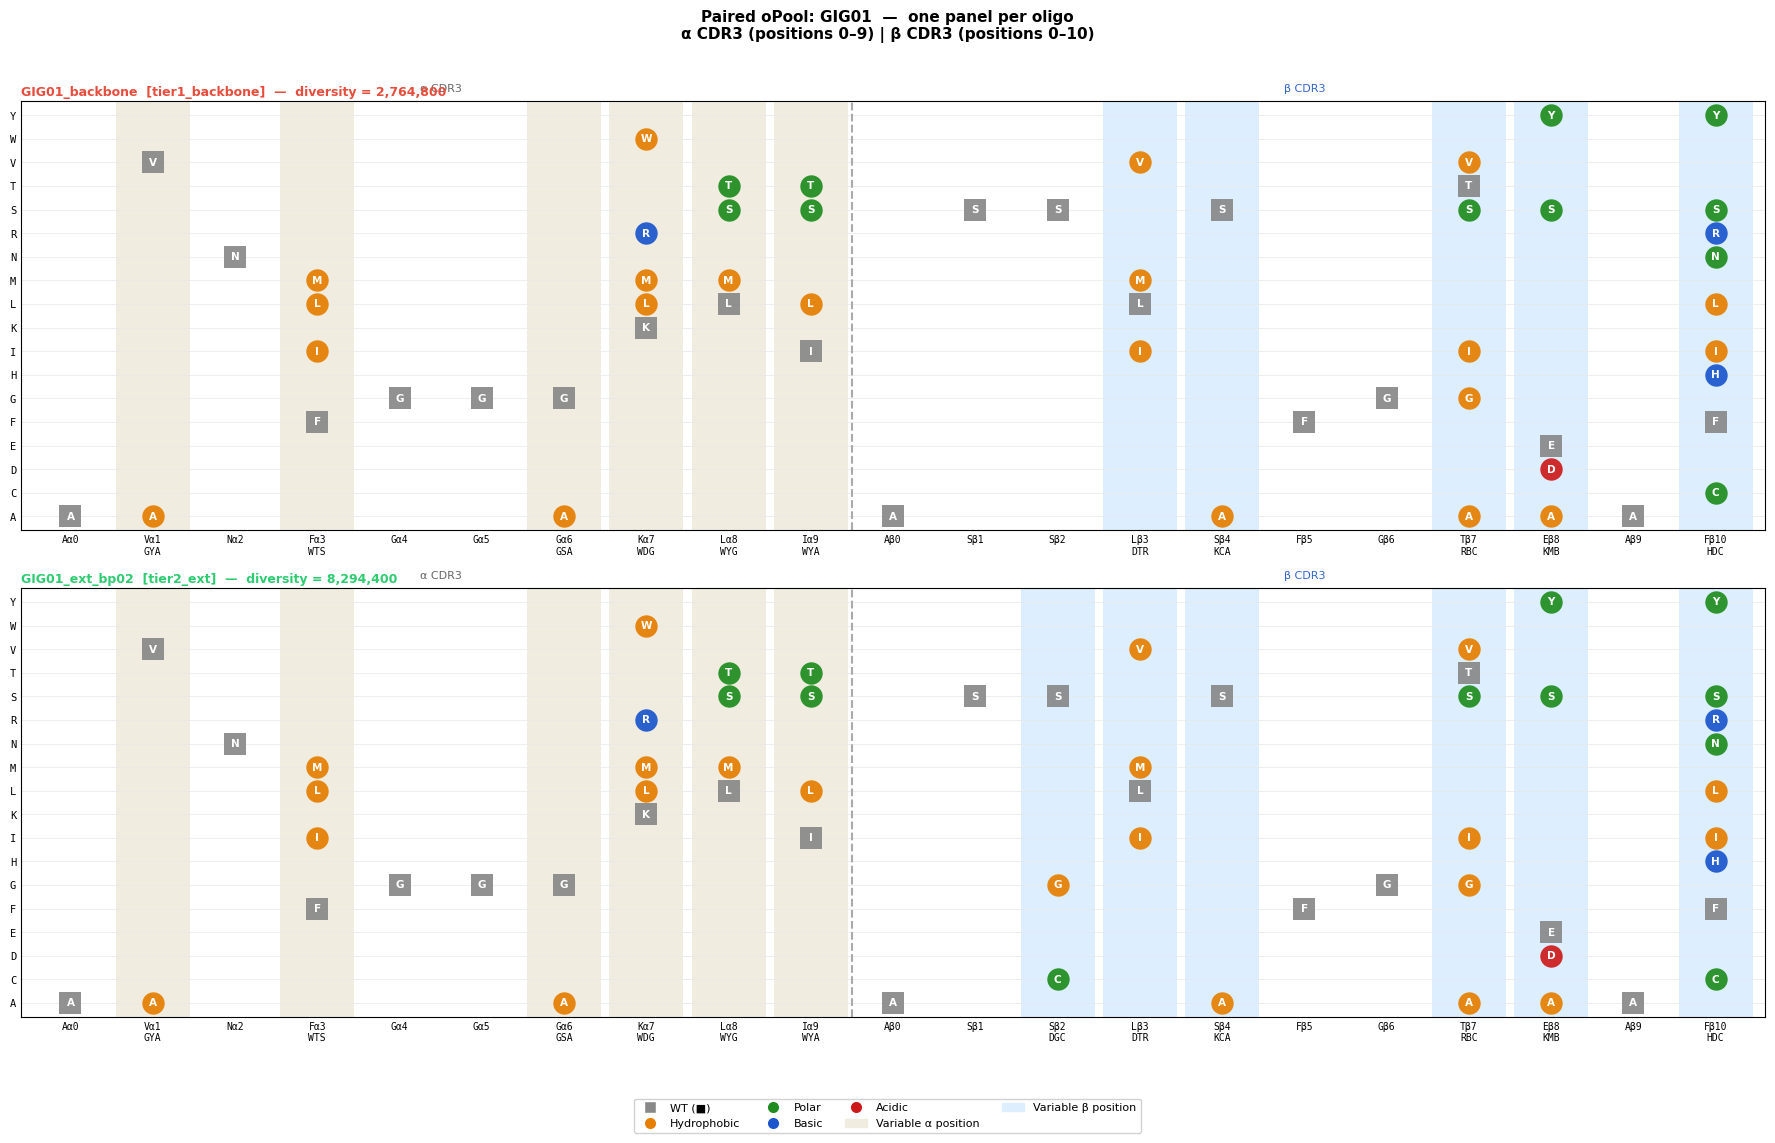

Saved → /cluster/project/reddy/marluca/NGS_pipeline/notebooks/opool_designs_tcraft/opool_paired_GIG01_t0.33_tk0_per_oligo.pdf


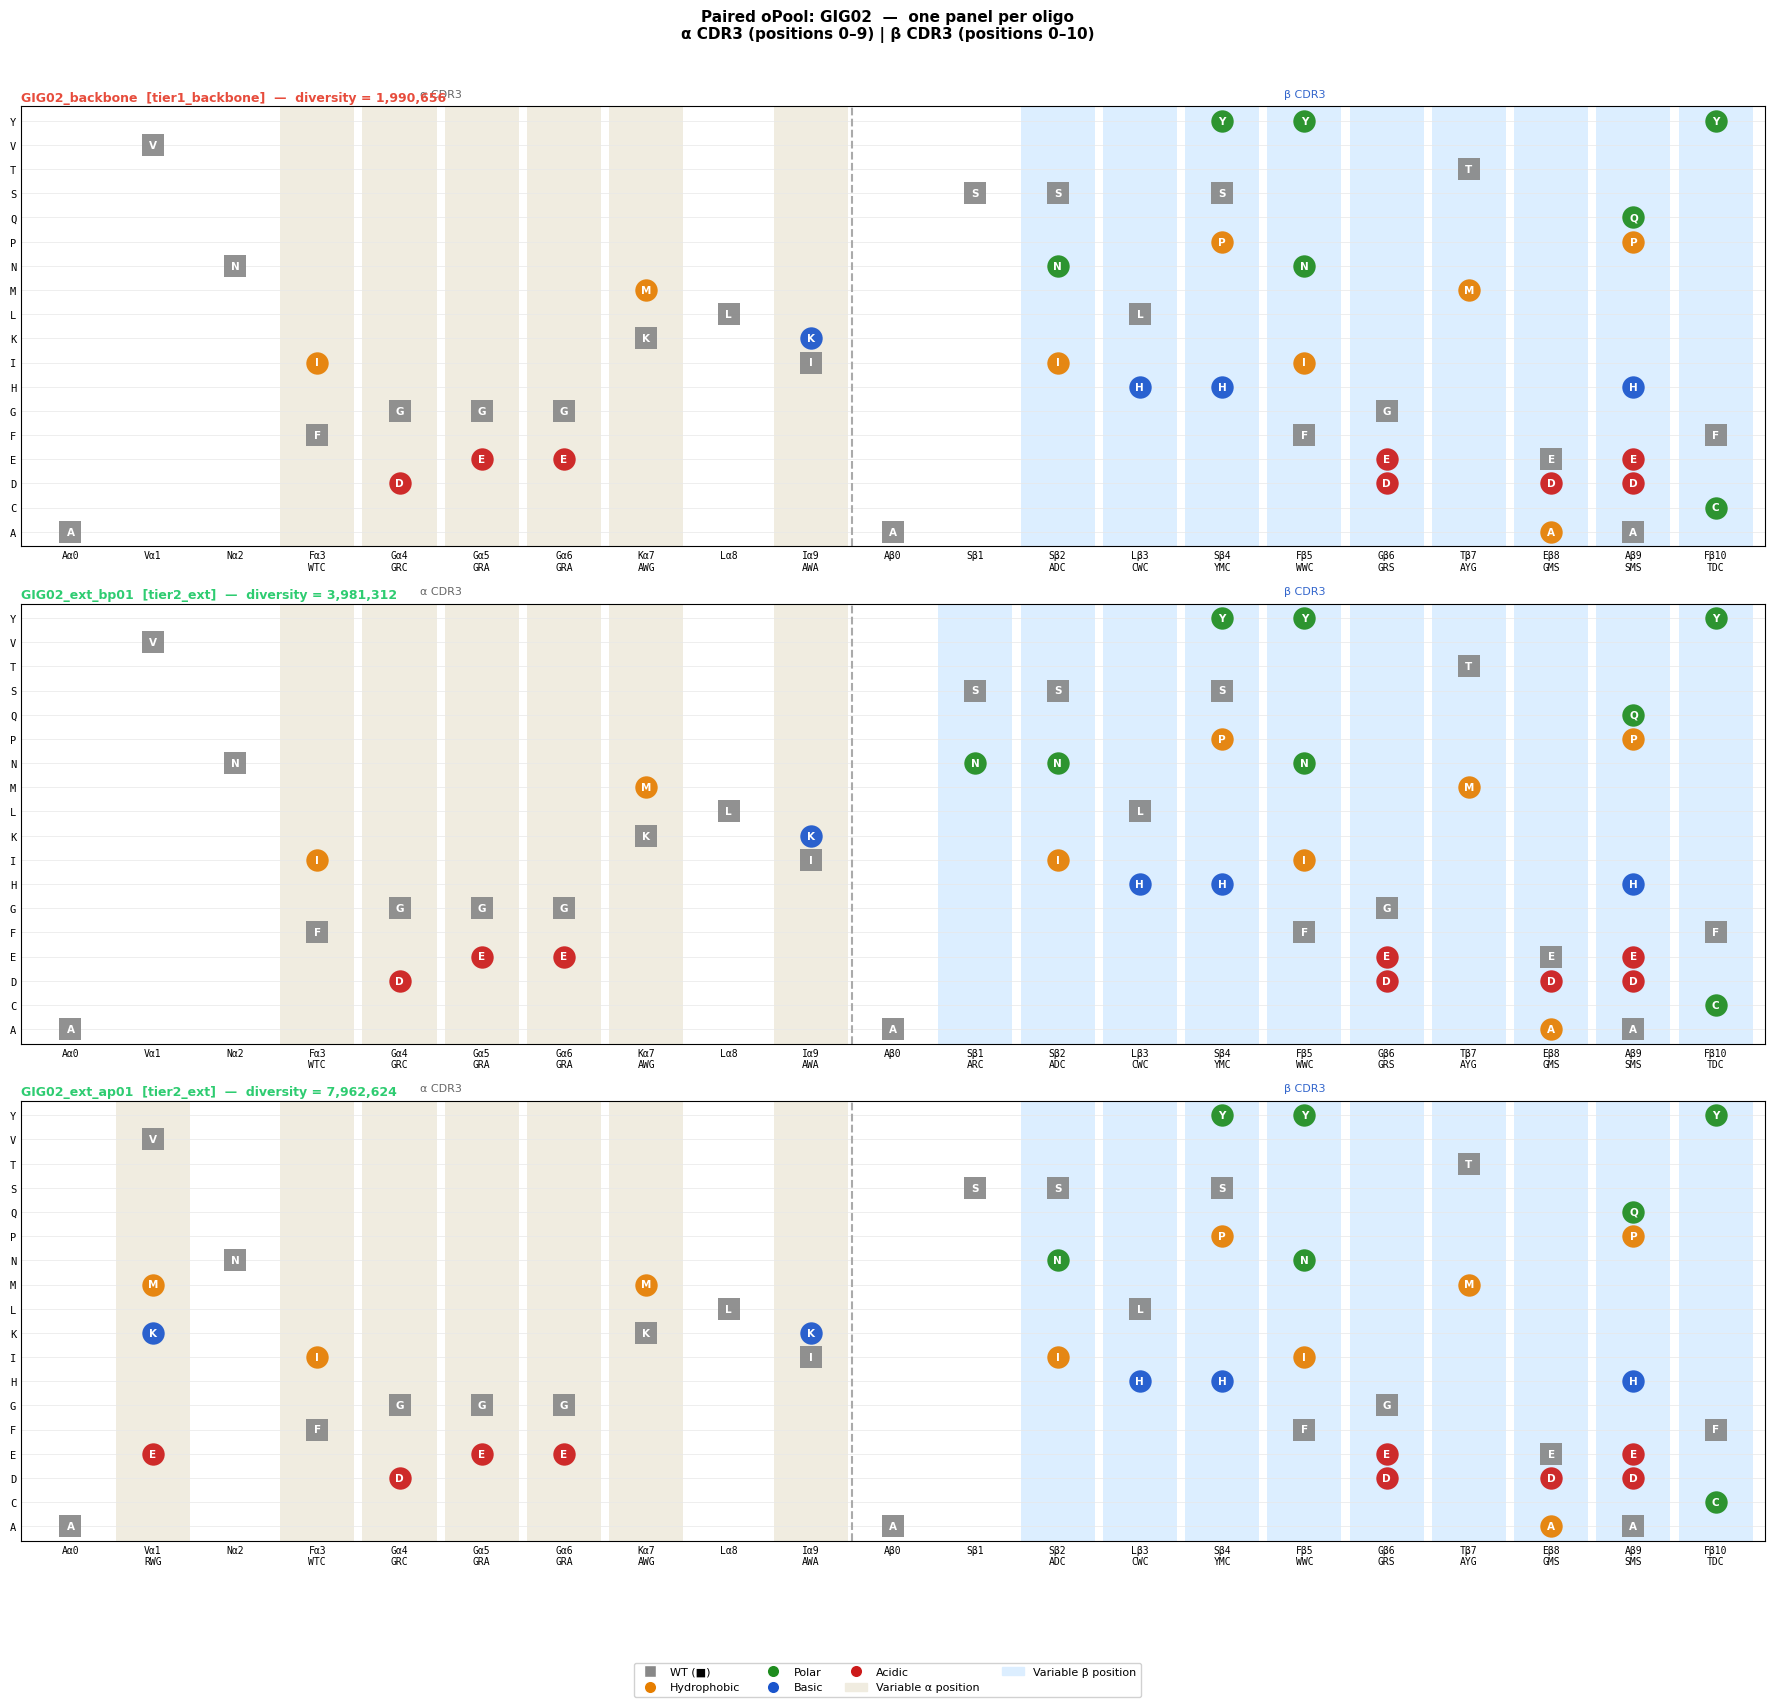

Saved → /cluster/project/reddy/marluca/NGS_pipeline/notebooks/opool_designs_tcraft/opool_paired_GIG02_t0.33_tk0_per_oligo.pdf


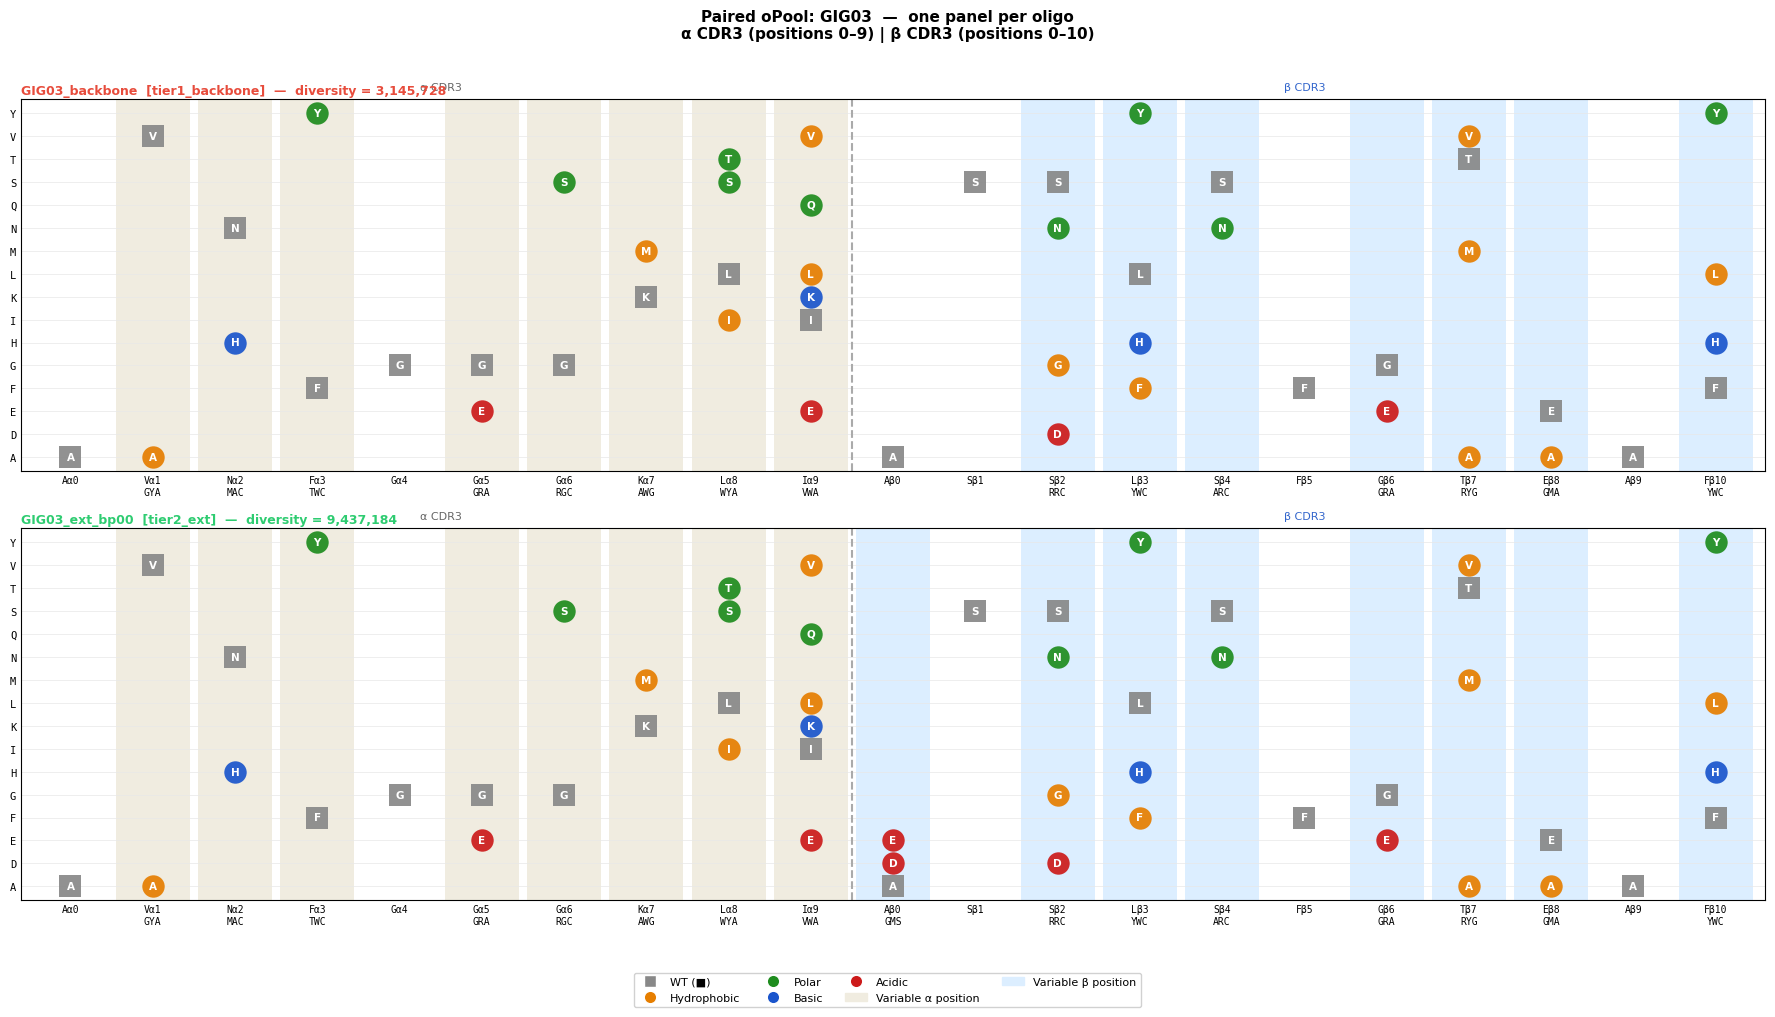

Saved → /cluster/project/reddy/marluca/NGS_pipeline/notebooks/opool_designs_tcraft/opool_paired_GIG03_t0.33_tk0_per_oligo.pdf


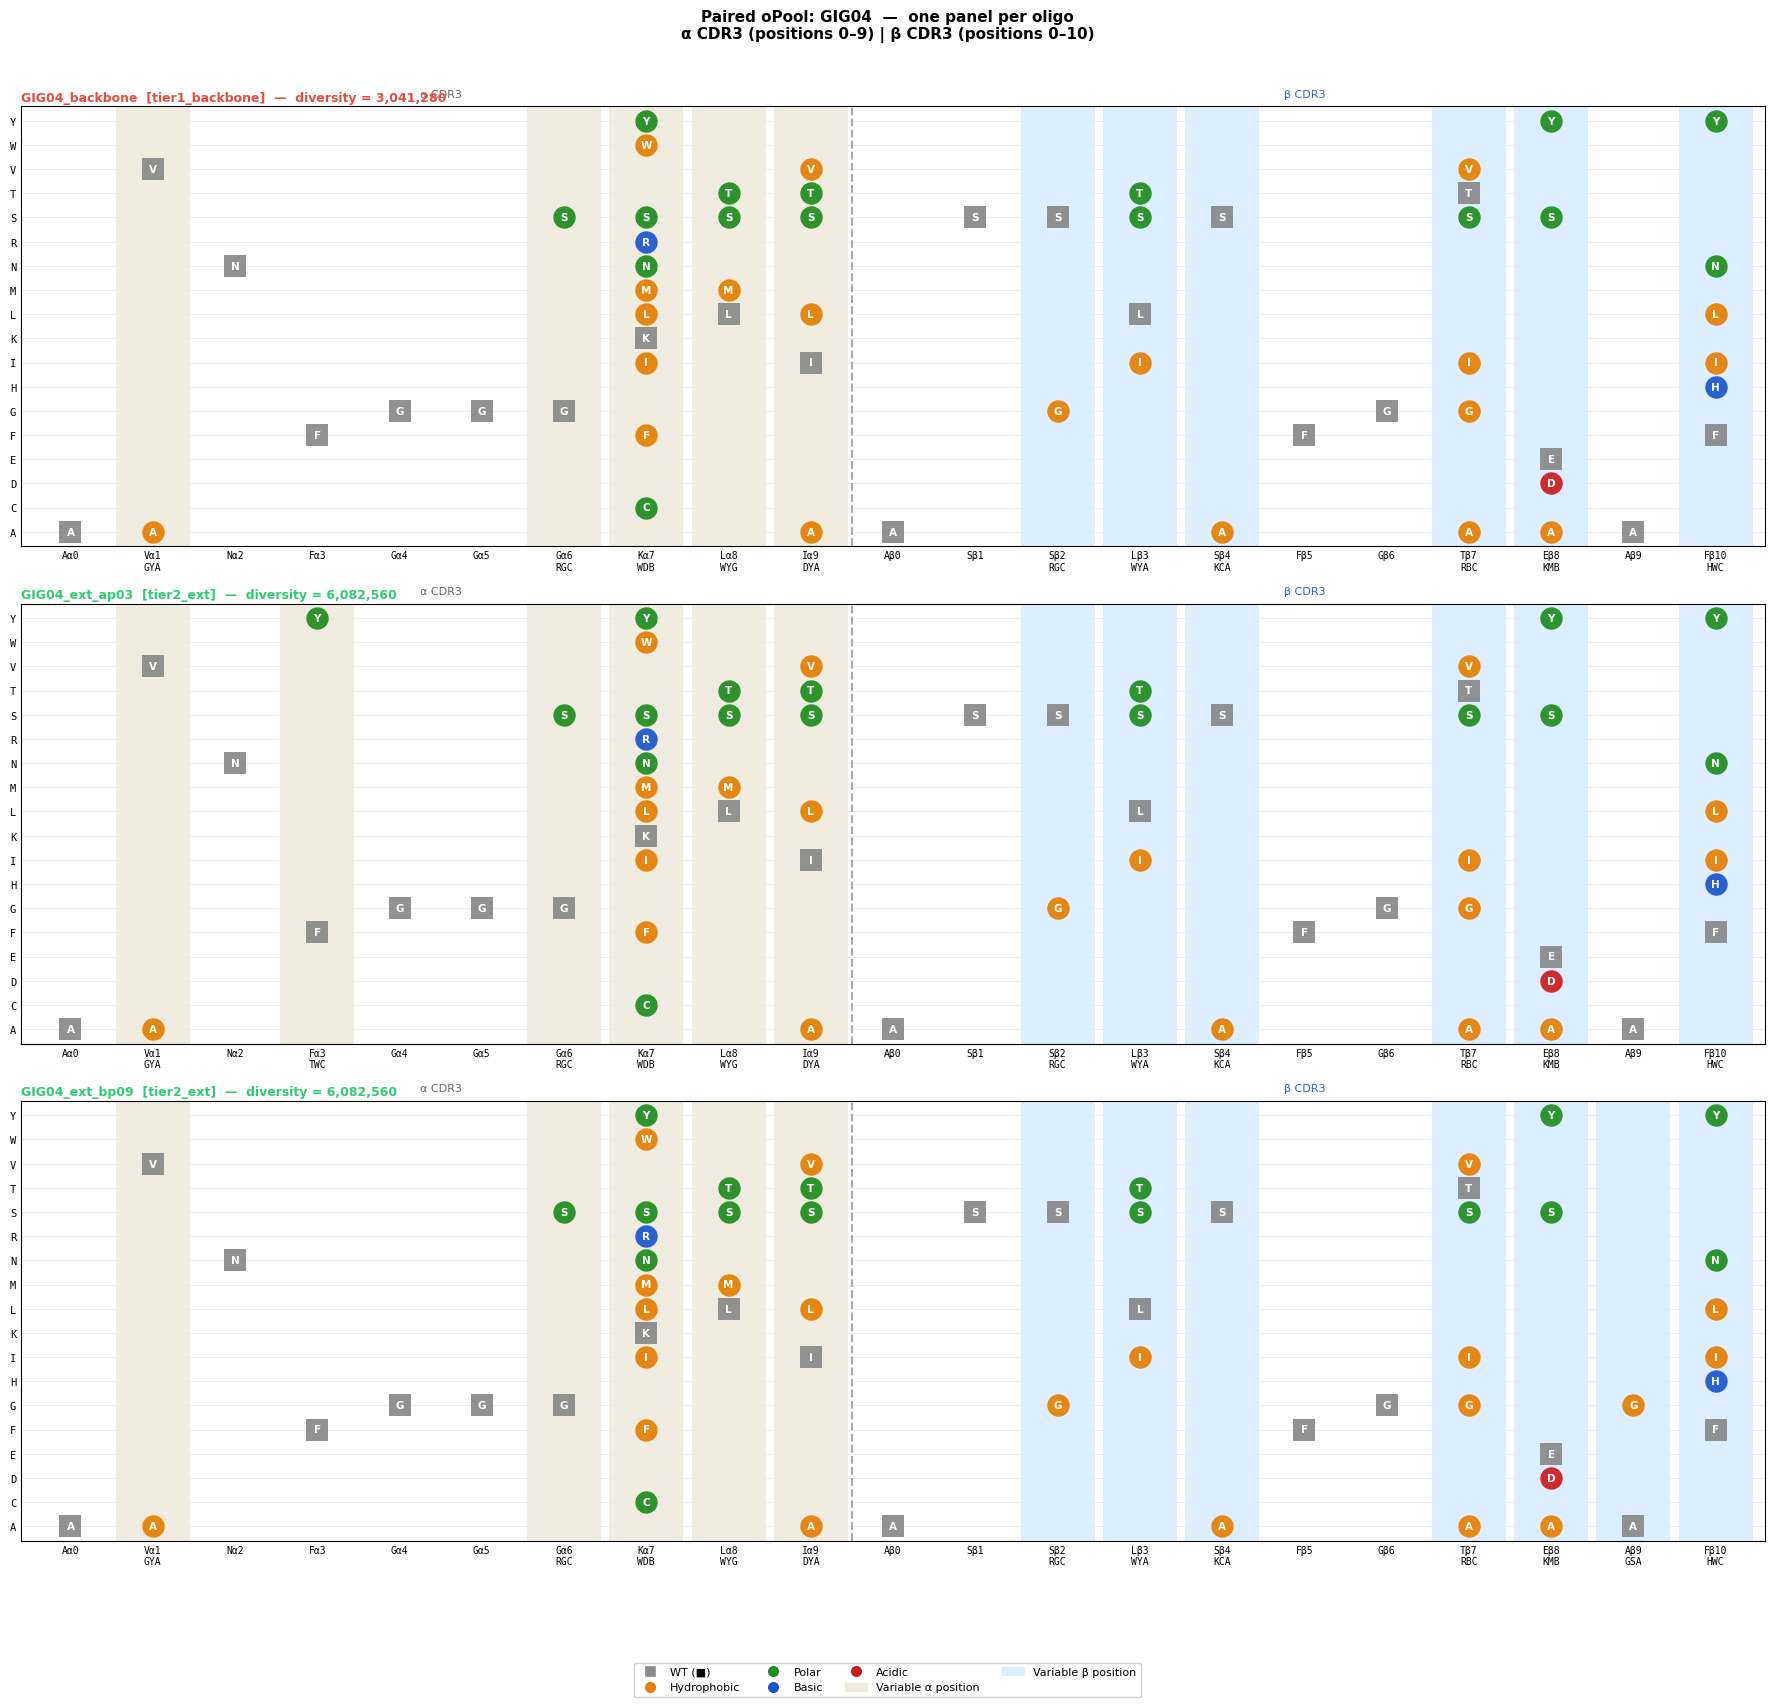

Saved → /cluster/project/reddy/marluca/NGS_pipeline/notebooks/opool_designs_tcraft/opool_paired_GIG04_t0.33_tk0_per_oligo.pdf


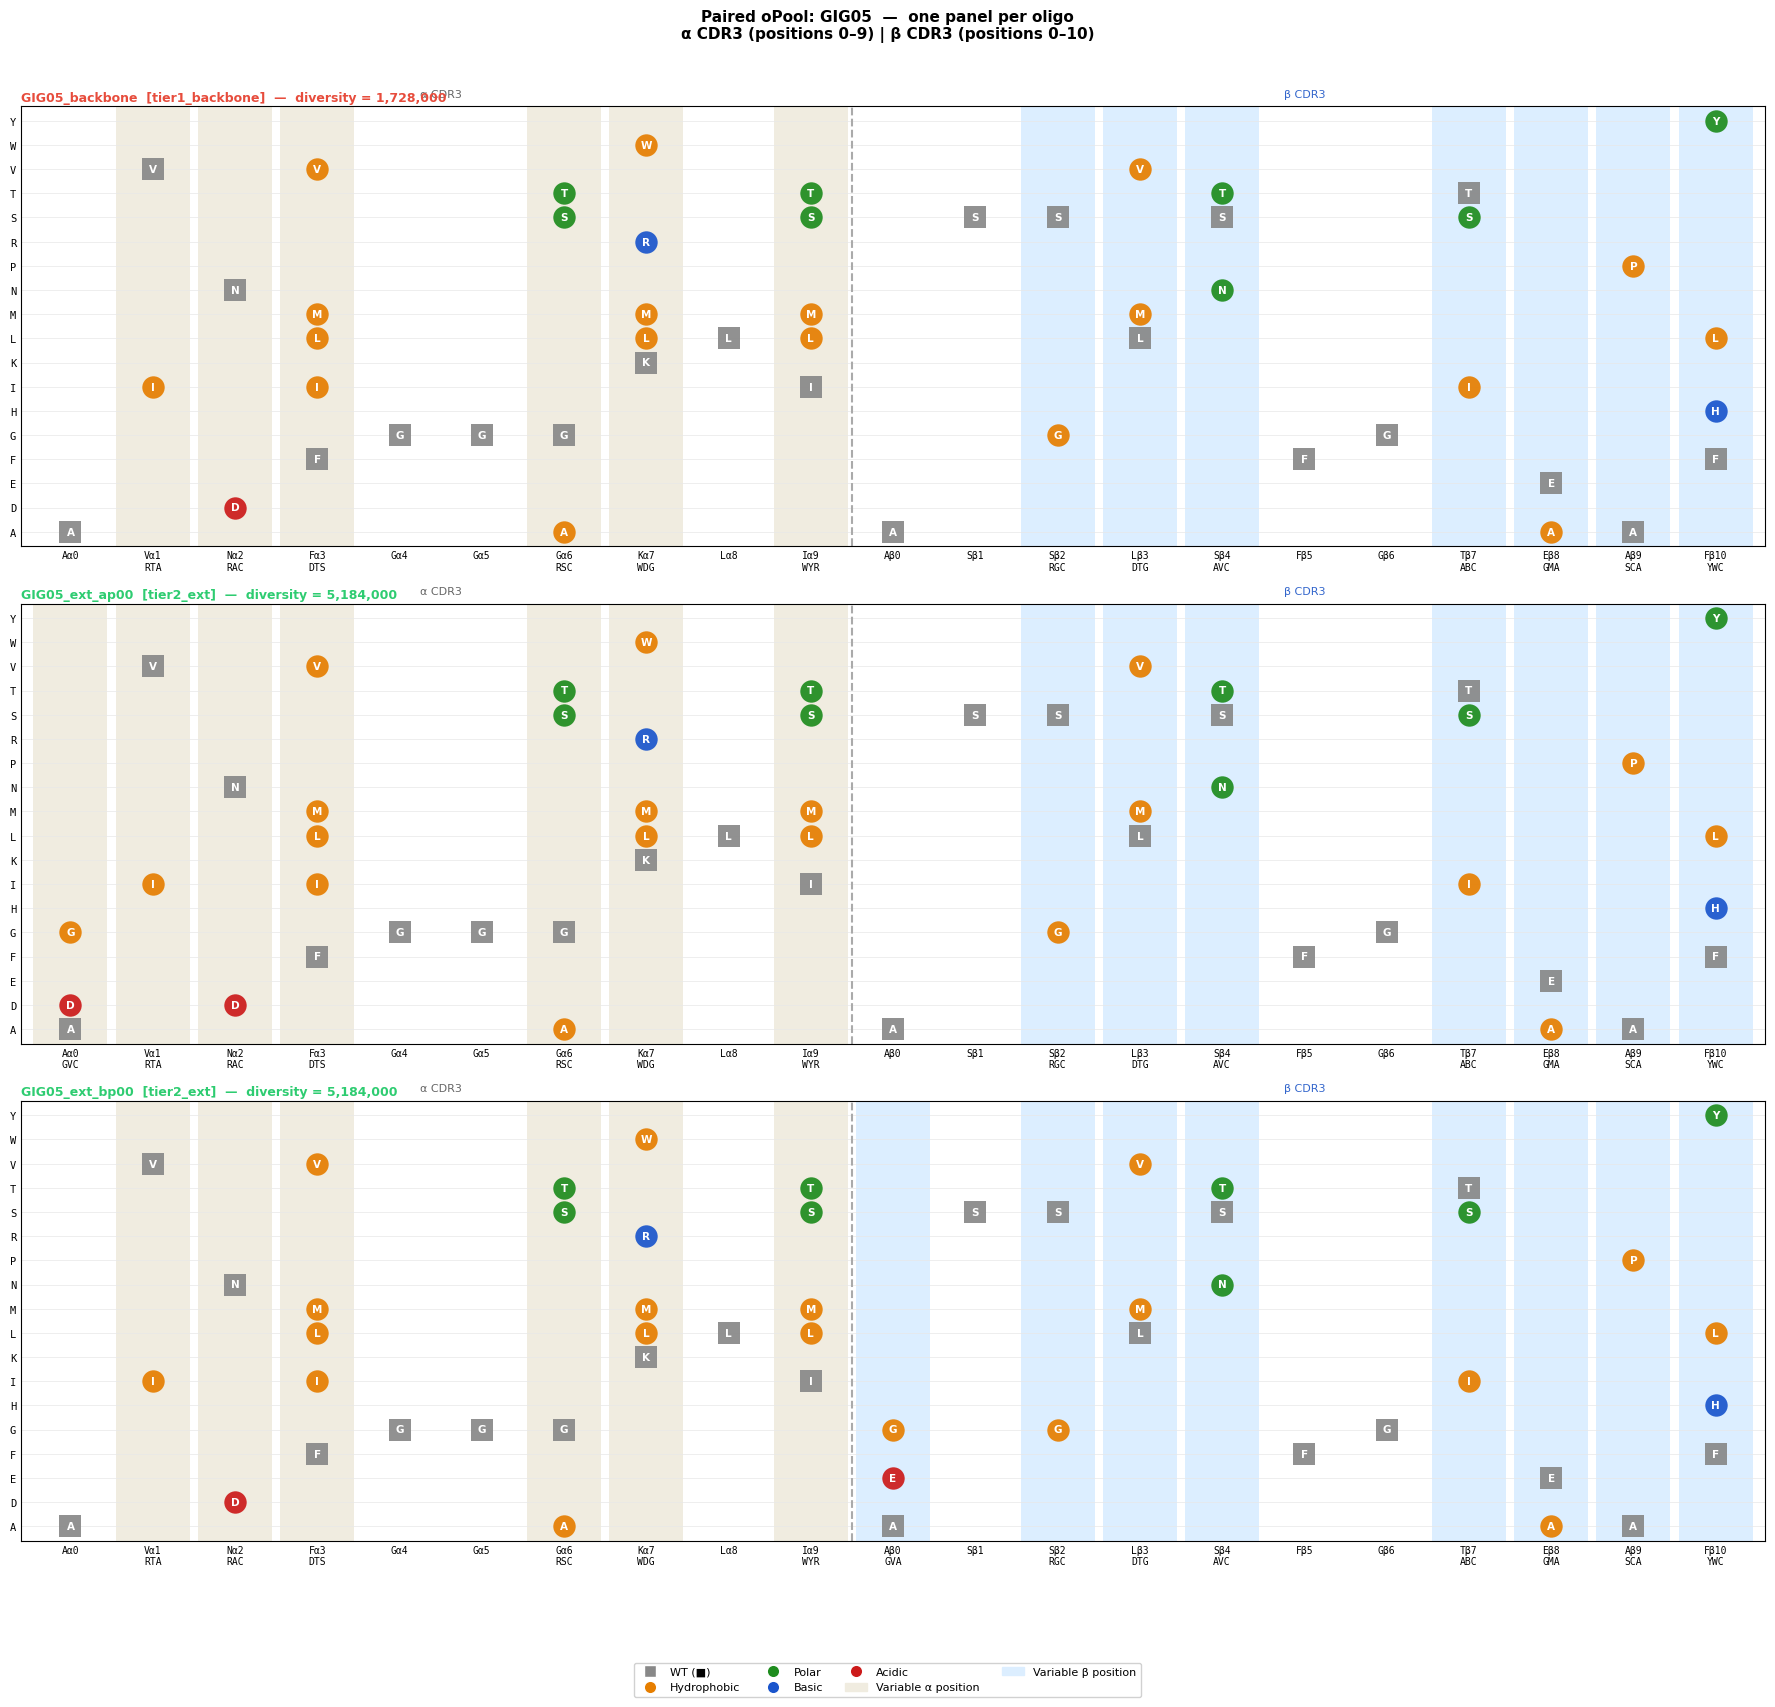

Saved → /cluster/project/reddy/marluca/NGS_pipeline/notebooks/opool_designs_tcraft/opool_paired_GIG05_t0.33_tk0_per_oligo.pdf


In [9]:
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

AA_CHEM = {
    'A':'#e67e00','G':'#e67e00','V':'#e67e00','I':'#e67e00','L':'#e67e00',
    'M':'#e67e00','F':'#e67e00','W':'#e67e00','P':'#e67e00',
    'S':'#1e8c1e','T':'#1e8c1e','C':'#1e8c1e','Y':'#1e8c1e',
    'N':'#1e8c1e','Q':'#1e8c1e',
    'K':'#1a55cc','R':'#1a55cc','H':'#1a55cc',
    'D':'#cc1a1a','E':'#cc1a1a',
}
WT_COL = '#888888'
OLIGO_TYPE_COLOR = {'tier1_backbone': '#e74c3c', 'tier2_ext': '#2ecc71'}
SEP_X = ALPHA_LEN - 0.5   # vertical separator between alpha and beta sections


def plot_paired_pool(pep, pool):
    n_total = ALPHA_LEN + BETA_LEN   # 21 positions on x-axis

    all_aas = sorted({
        aa
        for o in pool
        for aas_dict in [o['alpha_position_aas'], o['beta_position_aas']]
        for aas in aas_dict.values()
        for aa in aas
    })
    aa_y   = {aa: i for i, aa in enumerate(all_aas)}
    n_aa   = len(all_aas)
    row_h  = max(3.0, n_aa * 0.32)

    n_oligos = len(pool)
    fig, axes = plt.subplots(n_oligos, 1,
                             figsize=(max(14, n_total * 0.85), row_h * n_oligos),
                             squeeze=False)

    for ax, oligo in zip(axes[:, 0], pool):
        # Shade variable positions
        for pos in range(ALPHA_LEN):
            if len(oligo['alpha_position_aas'][pos]) > 1:
                ax.axvspan(pos - 0.45, pos + 0.45, color='#f0ece0', zorder=0, lw=0)
        for pos in range(BETA_LEN):
            x = ALPHA_LEN + pos
            if len(oligo['beta_position_aas'][pos]) > 1:
                ax.axvspan(x - 0.45, x + 0.45, color='#dceeff', zorder=0, lw=0)

        # Chain separator
        ax.axvline(SEP_X, color='#aaaaaa', linewidth=1.5, linestyle='--', zorder=2)

        # Alpha positions
        for pos in range(ALPHA_LEN):
            wt_aa = WT_ALPHA[pos]
            for aa in sorted(oligo['alpha_position_aas'][pos]):
                color  = WT_COL if aa == wt_aa else AA_CHEM.get(aa, '#555555')
                marker = 's' if aa == wt_aa else 'o'
                ax.scatter(pos, aa_y[aa], s=260, color=color,
                           marker=marker, alpha=0.92, zorder=3, linewidths=0)
                ax.text(pos, aa_y[aa], aa, ha='center', va='center',
                        fontsize=7.5, fontweight='bold', color='white', zorder=4)

        # Beta positions
        for pos in range(BETA_LEN):
            x = ALPHA_LEN + pos
            wt_aa = WT_BETA[pos]
            for aa in sorted(oligo['beta_position_aas'][pos]):
                color  = WT_COL if aa == wt_aa else AA_CHEM.get(aa, '#555555')
                marker = 's' if aa == wt_aa else 'o'
                ax.scatter(x, aa_y[aa], s=260, color=color,
                           marker=marker, alpha=0.92, zorder=3, linewidths=0)
                ax.text(x, aa_y[aa], aa, ha='center', va='center',
                        fontsize=7.5, fontweight='bold', color='white', zorder=4)

        ax.set_xlim(-0.6, n_total - 0.4)
        ax.set_ylim(-0.6, n_aa - 0.4)
        ax.set_xticks(range(n_total))

        xlabels = []
        for i in range(ALPHA_LEN):
            base = f'{WT_ALPHA[i]}\u03b1{i}'
            if len(oligo['alpha_position_aas'][i]) > 1:
                xlabels.append(f'{base}\n{oligo["alpha_iupac"][i]}')
            else:
                xlabels.append(base)
        for i in range(BETA_LEN):
            base = f'{WT_BETA[i]}\u03b2{i}'
            if len(oligo['beta_position_aas'][i]) > 1:
                xlabels.append(f'{base}\n{oligo["beta_iupac"][i]}')
            else:
                xlabels.append(base)
        ax.set_xticklabels(xlabels, fontsize=7, fontfamily='monospace')

        ax.set_yticks(range(n_aa))
        ax.set_yticklabels(all_aas, fontsize=7.5, fontfamily='monospace')
        ax.tick_params(axis='x', length=0, pad=3)
        ax.tick_params(axis='y', length=0)
        ax.set_axisbelow(True)
        ax.yaxis.grid(True, color='#e8e8e8', linewidth=0.5)

        # Chain labels
        ax.text(ALPHA_LEN / 2 - 0.5, n_aa - 0.1, '\u03b1 CDR3',
                ha='center', va='bottom', fontsize=8, color='#666666')
        ax.text(ALPHA_LEN + BETA_LEN / 2 - 0.5, n_aa - 0.1, '\u03b2 CDR3',
                ha='center', va='bottom', fontsize=8, color='#3366cc')

        otype = oligo['oligo_type']
        tc    = OLIGO_TYPE_COLOR.get(otype, '#555')
        ax.set_title(
            f"{oligo['oligo_id']}  [{otype}]  —  diversity = {oligo['diversity']:,}",
            fontsize=9, loc='left', pad=4, color=tc, fontweight='bold',
        )

    legend_handles = [
        mlines.Line2D([], [], marker='s', color='w', markerfacecolor=WT_COL, markersize=9, label='WT (\u25a0)'),
        mlines.Line2D([], [], marker='o', color='w', markerfacecolor='#e67e00', markersize=9, label='Hydrophobic'),
        mlines.Line2D([], [], marker='o', color='w', markerfacecolor='#1e8c1e', markersize=9, label='Polar'),
        mlines.Line2D([], [], marker='o', color='w', markerfacecolor='#1a55cc', markersize=9, label='Basic'),
        mlines.Line2D([], [], marker='o', color='w', markerfacecolor='#cc1a1a', markersize=9, label='Acidic'),
        mpatches.Patch(color='#f0ece0', label='Variable \u03b1 position'),
        mpatches.Patch(color='#dceeff', label='Variable \u03b2 position'),
    ]
    fig.legend(handles=legend_handles, loc='lower center', ncol=4,
               fontsize=8, bbox_to_anchor=(0.5, 0.0), framealpha=0.9)
    fig.suptitle(f'Paired oPool: {pep}  —  one panel per oligo\n'
                 f'\u03b1 CDR3 (positions 0\u20139) | \u03b2 CDR3 (positions 0\u201310)',
                 fontsize=11, fontweight='bold')
    plt.tight_layout(rect=[0, 0.07, 1, 0.97])

    pdf = OUT_DIR / f'opool_paired_{pep}_t{TIER1_FRAC}_tk{TOP_K}_per_oligo.pdf'
    png = OUT_DIR / f'opool_paired_{pep}_t{TIER1_FRAC}_tk{TOP_K}_per_oligo.png'
    plt.savefig(pdf, bbox_inches='tight')
    plt.savefig(png, bbox_inches='tight', dpi=150)
    plt.show()
    print(f'Saved \u2192 {pdf}')


for pep in PEPTIDES:
    plot_paired_pool(pep, POOLS[pep])

## Export to CSV

One CSV per peptide.  The `paired_dna` column contains `alpha_dna + beta_dna` with no adapters — add those externally once the TCRAFT cloning adapters are finalised.

In [10]:
def pool_to_df(pep, pool):
    rows, cumul = [], 0
    for o in pool:
        cumul += o['unique_diversity']
        alpha_var = '; '.join(
            f'p{p}:[{",".join(sorted(o["alpha_position_aas"][p]))}]'
            for p in o['alpha_varied_pos']
        )
        beta_var = '; '.join(
            f'p{p}:[{",".join(sorted(o["beta_position_aas"][p]))}]'
            for p in o['beta_varied_pos']
        )
        effs = [e for e in o['codon_efficiency'].values() if e < 1.0]
        rows.append({
            'oligo_id':               o['oligo_id'],
            'oligo_type':             o['oligo_type'],
            'alpha_dna':              o['alpha_dna'],
            'beta_dna':               o['beta_dna'],
            'paired_dna':             o['paired_dna'],
            'paired_dna_length_nt':   len(o['paired_dna']),
            'n_alpha_varied':         o['n_alpha_varied'],
            'n_beta_varied':          o['n_beta_varied'],
            'alpha_varied_positions': alpha_var,
            'beta_varied_positions':  beta_var,
            'diversity':              o['diversity'],
            'unique_diversity':       o['unique_diversity'],
            'cumulative_diversity':   cumul,
            'mean_codon_efficiency':  round(np.mean(effs), 3) if effs else 1.0,
            'is_leaky':               o.get('is_leaky', False),
        })
    return pd.DataFrame(rows)


idt_rows = []
for pep, pool in POOLS.items():
    df   = pool_to_df(pep, pool)
    path = OUT_DIR / f'opool_paired_{pep}.csv'
    df.to_csv(path, index=False)
    print(f'Wrote {path}  ({len(df)} oligos)')
    display(df[['oligo_id','oligo_type','alpha_dna','beta_dna',
                'n_alpha_varied','n_beta_varied','diversity','unique_diversity']])
    order = df[['oligo_id', 'paired_dna']].copy()
    order.insert(0, 'Pool Name', pep)
    idt_rows.append(order)

idt_df   = pd.concat(idt_rows, ignore_index=True)
idt_df   = idt_df.rename(columns={'oligo_id': 'Sequence Name', 'paired_dna': 'Sequence (no adapters)'})
idt_path = OUT_DIR / 'IDT_opool_paired_order.csv'
idt_df.to_csv(idt_path, index=False)
print(f'\nIDT order sheet (adapters TBD) → {idt_path}  ({len(idt_df)} oligos total)')
display(idt_df)

Wrote /cluster/project/reddy/marluca/NGS_pipeline/notebooks/opool_designs_tcraft/opool_paired_DRG01.csv  (4 oligos)


,oligo_id,oligo_type,alpha_dna,beta_dna,n_alpha_varied,n_beta_varied,diversity,unique_diversity
0,DRG01_backbone,tier1_backbone,GCAGYAAACWTSGGAGGAGGADWGWTGWTR,GCAAGCYCAMKGKYATTCGGAAVARWARCABNH,5,7,1935360,1935360
1,DRG01_ext_ap00,tier2_ext,GSAGYAAACWTSGGAGGAGGADWGWTGWTR,GCAAGCYCAMKGKYATTCGGAAVARWARCABNH,6,7,3870720,1935360
2,DRG01_ext_bp01,tier2_ext,GCAGYAAACWTSGGAGGAGGADWGWTGWTR,GCATMCYCAMKGKYATTCGGAAVARWARCABNH,5,8,3870720,1935360
3,DRG01_ext_ap02,tier2_ext,GCAGYAMACWTSGGAGGAGGADWGWTGWTR,GCAAGCYCAMKGKYATTCGGAAVARWARCABNH,6,7,3870720,1935360


Wrote /cluster/project/reddy/marluca/NGS_pipeline/notebooks/opool_designs_tcraft/opool_paired_DRG04.csv  (2 oligos)


,oligo_id,oligo_type,alpha_dna,beta_dna,n_alpha_varied,n_beta_varied,diversity,unique_diversity
0,DRG04_backbone,tier1_backbone,GCAGYAAACWTSGGAGGARGCWDGWYGDYR,GCAAGCRGCDTRKCATTCGGARYGBMAGCAYWC,6,6,2867200,2867200
1,DRG04_ext_ap00,tier2_ext,GVCGYAAACWTSGGAGGARGCWDGWYGDYR,GCAAGCRGCDTRKCATTCGGARYGBMAGCAYWC,7,6,8601600,5734400


Wrote /cluster/project/reddy/marluca/NGS_pipeline/notebooks/opool_designs_tcraft/opool_paired_GIG01.csv  (2 oligos)


...

,oligo_id,oligo_type,alpha_dna,beta_dna,n_alpha_varied,n_beta_varied,diversity,unique_diversity
0,GIG04_backbone,tier1_backbone,GCAGYAAACTTCGGAGGARGCWDBWYGDYA,GCAAGCRGCWYAKCATTCGGARBCKMBGCAHWC,5,6,3041280,3041280
1,GIG04_ext_ap03,tier2_ext,GCAGYAAACTWCGGAGGARGCWDBWYGDYA,GCAAGCRGCWYAKCATTCGGARBCKMBGCAHWC,6,6,6082560,3041280
2,GIG04_ext_bp09,tier2_ext,GCAGYAAACTTCGGAGGARGCWDBWYGDYA,GCAAGCRGCWYAKCATTCGGARBCKMBGSAHWC,5,7,6082560,3041280


Wrote /cluster/project/reddy/marluca/NGS_pipeline/notebooks/opool_designs_tcraft/opool_paired_GIG05.csv  (3 oligos)


,oligo_id,oligo_type,alpha_dna,beta_dna,n_alpha_varied,n_beta_varied,diversity,unique_diversity
0,GIG05_backbone,tier1_backbone,GCARTARACDTSGGAGGARSCWDGCTAWYR,GCAAGCRGCDTGAVCTTCGGAABCGMASCAYWC,6,7,1728000,1728000
1,GIG05_ext_ap00,tier2_ext,GVCRTARACDTSGGAGGARSCWDGCTAWYR,GCAAGCRGCDTGAVCTTCGGAABCGMASCAYWC,7,7,5184000,3456000
2,GIG05_ext_bp00,tier2_ext,GCARTARACDTSGGAGGARSCWDGCTAWYR,GVAAGCRGCDTGAVCTTCGGAABCGMASCAYWC,6,8,5184000,3456000



IDT order sheet (adapters TBD) → /cluster/project/reddy/marluca/NGS_pipeline/notebooks/opool_designs_tcraft/IDT_opool_paired_order.csv  (19 oligos total)


,Pool Name,Sequence Name,Sequence (no adapters)
0,DRG01,DRG01_backbone,GCAGYAAACWTSGGAGGAGGADWGWTGWTRGCAAGCYCAMKGKYAT...
1,DRG01,DRG01_ext_ap00,GSAGYAAACWTSGGAGGAGGADWGWTGWTRGCAAGCYCAMKGKYAT...
2,DRG01,DRG01_ext_bp01,GCAGYAAACWTSGGAGGAGGADWGWTGWTRGCATMCYCAMKGKYAT...
3,DRG01,DRG01_ext_ap02,GCAGYAMACWTSGGAGGAGGADWGWTGWTRGCAAGCYCAMKGKYAT...
4,DRG04,DRG04_backbone,GCAGYAAACWTSGGAGGARGCWDGWYGDYRGCAAGCRGCDTRKCAT...
5,DRG04,DRG04_ext_ap00,GVCGYAAACWTSGGAGGARGCWDGWYGDYRGCAAGCRGCDTRKCAT...
6,GIG01,GIG01_backbone,GCAGYAAACWTSGGAGGAGSAWDGWYGWYAGCAAGCAGCDTRKCAT...
7,GIG01,GIG01_ext_bp02,GCAGYAAACWTSGGAGGAGSAWDGWYGWYAGCAAGCDGCDTRKCAT...
8,GIG02,GIG02_backbone,GCAGTAAACWTCGRCGRAGRAAWGCTAAWAGCAAGCADCCWCYMCW...
9,GIG02,GIG02_ext_bp01,GCAGTAAACWTCGRCGRAGRAAWGCTAAWAGCAARCADCCWCYMCW...
